# Sales Data Analysis Project

## Loading Of Data


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


# Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data


In [11]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Data Understanding

In [13]:
df.shape

(9994, 21)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [15]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# Data Cleaning

In [16]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extracting Time Features

In [19]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

# Exploratory Data Analysis

In [25]:

df['Sales'].sum()

np.float64(2297200.8603000003)

In [26]:
df['Profit'].sum()

np.float64(286397.0217)

In [27]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


Technology category generates the highest sales

In [28]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


Some categories have high sales but lower profit margins

In [29]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


West region generates the highest sales

In [30]:
monthly_sales = df.groupby('Month Name')['Sales'].sum()

monthly_sales = monthly_sales.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

monthly_sales

,Sales
Month Name,
January,94924.8356
February,59751.2514
March,205005.4888
April,137762.1286
May,155028.8117
June,152718.6793
July,147238.0970
August,159044.0630
September,307649.9457


In [33]:
monthly_sales.max()

352461.071

In [43]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


# Visualization

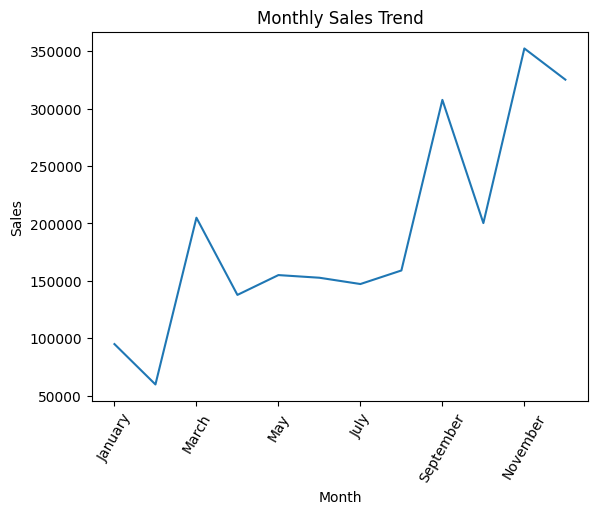

In [39]:
plt.figure()
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=60)
plt.show()

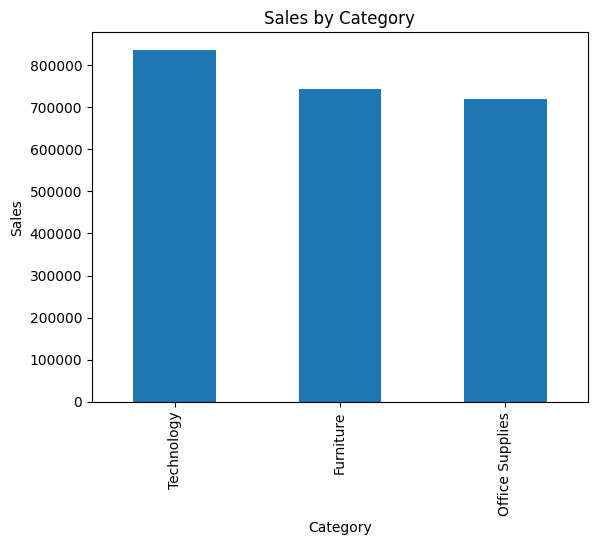

In [40]:
plt.figure()
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

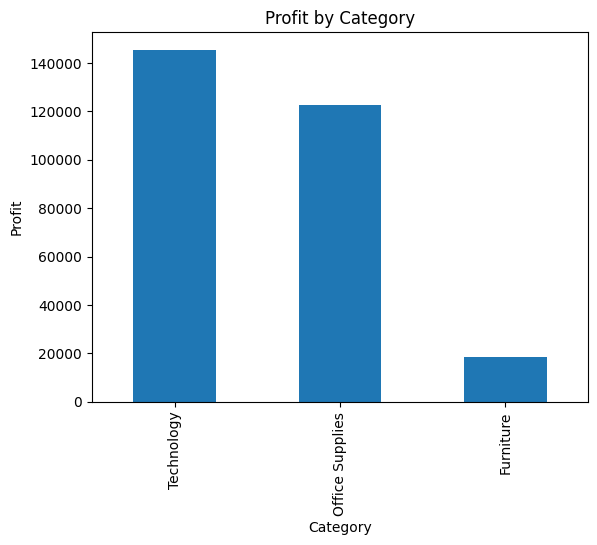

In [41]:
plt.figure()
category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

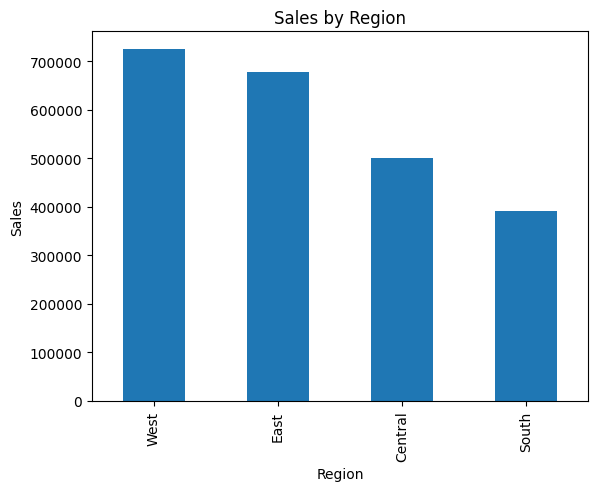

In [42]:
plt.figure()
region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

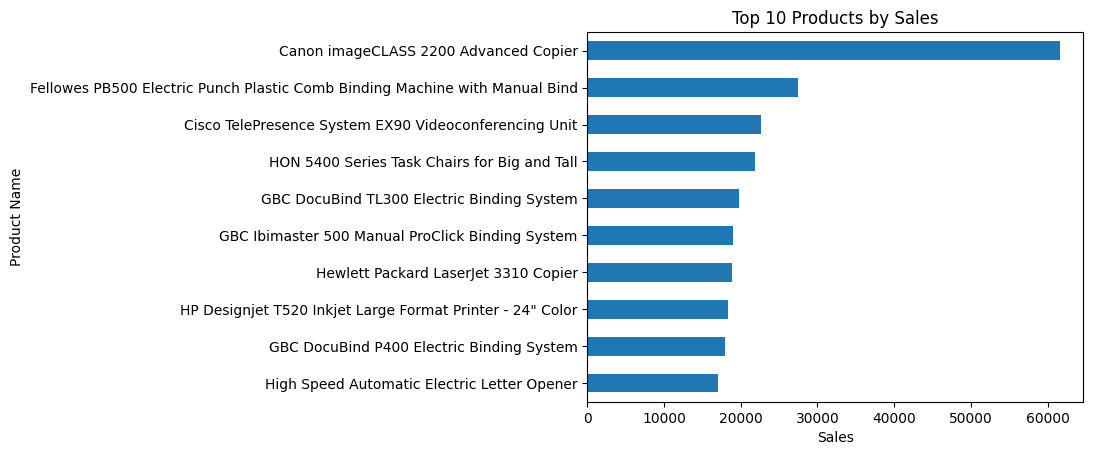

In [44]:
plt.figure()
top_products.plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.gca().invert_yaxis()
plt.show()

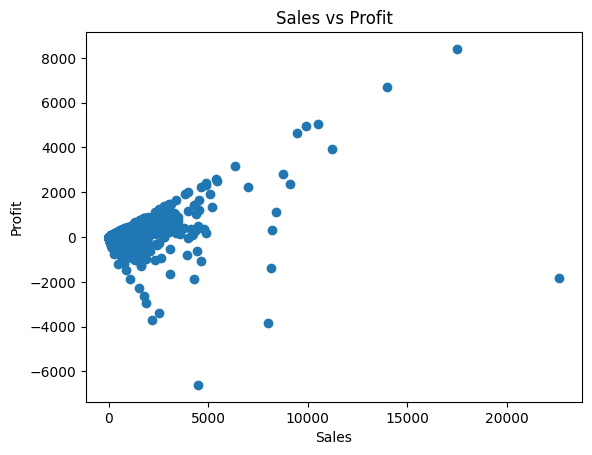

In [45]:
plt.figure()
plt.scatter(df['Sales'], df['Profit'])
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

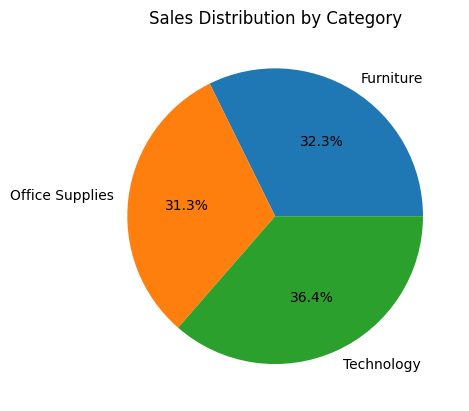

In [46]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure()
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Distribution by Category')
plt.ylabel('')
plt.show()

# Key Insights

Technology category generates the highest sales



Some categories have high sales but lower profit margins


Sales show variation across months (seasonality)


Certain regions outperform others(West region generates the highest sales)

Strong correlation between sales and profit is inconsistent → not all revenue is valuable

# Recommendations

Focus marketing on high-performing categories


Improve pricing strategy for low-profit products


Invest more in top-performing regions

Expand operations in high-profit regions

Re-evaluate pricing strategies for underperforming segments